In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/MER_T08_01__1_.csv')
df.head() #observing the dataset here!

,MSN,YYYYMM,Value,Column_Order,Description,Unit
0,NUOUPUS,195713,1,1,"Nuclear Generating Units, Total Operable Units",Number
1,NUOUPUS,195813,1,1,"Nuclear Generating Units, Total Operable Units",Number
2,NUOUPUS,195913,2,1,"Nuclear Generating Units, Total Operable Units",Number
3,NUOUPUS,196013,3,1,"Nuclear Generating Units, Total Operable Units",Number
4,NUOUPUS,196113,3,1,"Nuclear Generating Units, Total Operable Units",Number


At this point in the project, me and my group discovered that the data had to be split. The next few steps we split up the data based on the type of MSN. Even though we discovered that the MSN produced the same types of charts, datas, and results. All of the data

In [2]:
for msn, group in df.groupby("MSN"):
    filename = f"../data/MER_T08_01 (1)_{msn}.csv"
    group.to_csv(filename, index=False) #splitting the data into different CSV's based on the MSN, there are 5 different MSN's! This will be 5 seperate CSV files.

In [3]:
df = pd.read_csv('../data/MER_T08_01 (1)_NUGBPUS.csv')
print(df) #right now we are focusing on looking at the data from NUGBPUS

         MSN  YYYYMM   Value  Column_Order  \
0    NUGBPUS  195713   0.055             2   
1    NUGBPUS  195813   0.055             2   
2    NUGBPUS  195913   0.055             2   
3    NUGBPUS  196013   0.411             2   
4    NUGBPUS  196113   0.411             2   
..       ...     ...     ...           ...   
700  NUGBPUS  202509  96.880             2   
701  NUGBPUS  202510  96.880             2   
702  NUGBPUS  202511  96.880             2   
703  NUGBPUS  202512  96.880             2   
704  NUGBPUS  202513  96.880             2   

                                       Description               Unit  
0    Nuclear Generating Units, Net Summer Capacity  Million Kilowatts  
1    Nuclear Generating Units, Net Summer Capacity  Million Kilowatts  
2    Nuclear Generating Units, Net Summer Capacity  Million Kilowatts  
3    Nuclear Generating Units, Net Summer Capacity  Million Kilowatts  
4    Nuclear Generating Units, Net Summer Capacity  Million Kilowatts  
..             

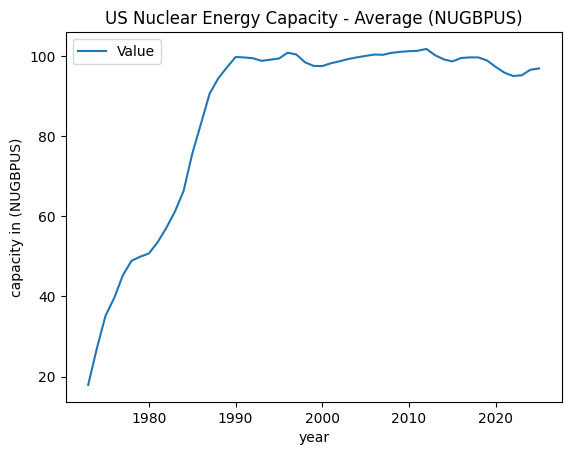

In [4]:
#This will convert the data which is thirteen to just a year.
df["Value"] = pd.to_numeric(df["Value"], errors="coerce") #convert Value to numeric so we can plot/aggregate it
df_monthly = df[~df["YYYYMM"].astype(str).str.endswith("13")].copy() #in this step everything that is 13 is culminated as data for a whole year.
df_monthly["YYYYMM"] = pd.to_datetime(
    df_monthly["YYYYMM"].astype(str), # ".astype(str)" is used for formatting the string correctly specifically within the context of date and time. This is important for data manipulation.
    #big thing I learned here was using the .astype(str) function and string manipulation. This is a concept we did not learn in class.
    format="%Y%m") #the '%Y%m, is for formatting, this is used for the formatting of the data correctly.

#converting all the dates and times into datetime frames and objects & visualizing the data.
df_yearly = df_monthly.groupby(df_monthly["YYYYMM"].dt.year)["Value"].mean().reset_index()
df_yearly.columns = ["Year", "Value"]
df_yearly.plot(x="Year", y="Value", kind="line")
plt.title("US Nuclear Energy Capacity - Average (NUGBPUS)")
plt.xlabel("year")
plt.ylabel("capacity in (NUGBPUS)")
plt.show()

In [5]:
df = pd.read_csv('../data/MER_T08_01 (1)_NUOUPUS.csv')
print(df)

         MSN  YYYYMM Value  Column_Order  \
0    NUOUPUS  195713     1             1   
1    NUOUPUS  195813     1             1   
2    NUOUPUS  195913     2             1   
3    NUOUPUS  196013     3             1   
4    NUOUPUS  196113     3             1   
..       ...     ...   ...           ...   
700  NUOUPUS  202509    94             1   
701  NUOUPUS  202510    94             1   
702  NUOUPUS  202511    94             1   
703  NUOUPUS  202512    94             1   
704  NUOUPUS  202513    94             1   

                                        Description    Unit  
0    Nuclear Generating Units, Total Operable Units  Number  
1    Nuclear Generating Units, Total Operable Units  Number  
2    Nuclear Generating Units, Total Operable Units  Number  
3    Nuclear Generating Units, Total Operable Units  Number  
4    Nuclear Generating Units, Total Operable Units  Number  
..                                              ...     ...  
700  Nuclear Generating Units, Total 

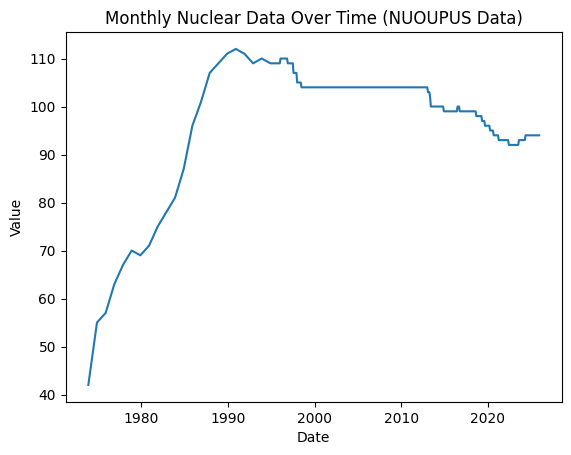

In [6]:
df_monthly = pd.read_csv("../data/MER_T08_01 (1)_NUOUPUS.csv") #now we are applying the same idea we used on the NUGBPUS dataset to NUOUPUS
df_monthly = df_monthly.copy()
df_monthly["Date"] = pd.to_datetime(
    df_monthly["YYYYMM"].astype(str),
    format="%Y%m",
    errors="coerce"
)
df_monthly = df_monthly.dropna(subset=["Date"])
df_monthly["Value"] = pd.to_numeric(df_monthly["Value"], errors="coerce")
df_monthly = df_monthly.dropna(subset=["Value"])
plt.plot(df_monthly["Date"], df_monthly["Value"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Monthly Nuclear Data Over Time (NUOUPUS Data)")
plt.show()

Before we perform linear regression methods specifically understanding prediction models, R^2 - which will give us information about how the dependent variable is influenced by the independent variable and other factors, we are going to quickly clean the data in terms of transforming the years into individual months so we can understand the data beter and have more specific information and data.

In [7]:
df["YYYYMM"] = df["YYYYMM"].astype(str)
df["Year"] = df["YYYYMM"].str[:4].astype(int) #Splitting year off. From beginning index to number four represents year.
df["Month"] = df["YYYYMM"].str[4:].astype(int) #Splitting the month off. From the fourth index to the end represents the month
print(df[["YYYYMM", "Year", "Month"]].head())
#These lines of codes are insanely relevant and important because we are transforming the data from a string into a numerical data form. In other words we are splitting the data into year and month.

   YYYYMM  Year  Month
0  195713  1957     13
1  195813  1958     13
2  195913  1959     13
3  196013  1960     13
4  196113  1961     13


In [8]:
df = df[df["Month"] <= 12] #Helps us ignore 13 which is the full year so we can understand monthly data
print(df["Month"].unique()) #The output validates this.

[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [9]:
df["Time"] = df["Year"] * 12 + df["Month"] #converting the years into months
print(df[["Year", "Month", "Time"]].head())

    Year  Month   Time
16  1973      1  23677
17  1973      2  23678
18  1973      3  23679
19  1973      4  23680
20  1973      5  23681


In [10]:
df = df.dropna(subset=["Value", "Time"]) #drops missing values (rows with missing values)
print(df[["Value", "Time"]].isna().sum())
df["Value"] = pd.to_numeric(df["Value"], errors="coerce") #this will help us convert the values to numeric which is important for this dataframe
df = df.dropna(subset=["Value", "Time"]) #Dropping values of NaN in the dataset.

Value    0
Time     0
dtype: int64


In [11]:
from sklearn.linear_model import LinearRegression #we are going to use a linear regression model to predict.

X = df[["Time"]]
y = df["Value"]

model = LinearRegression()
model.fit(X, y)

print("R^(2):", model.score(X, y))
print("coefficient:", model.coef_)
print("intercept:", model.intercept_)

R^(2): 0.011117154078070124
coefficient: [-0.00643405]
intercept: 255.61891659290768


In [12]:
df["Predicted"] = model.predict(X)

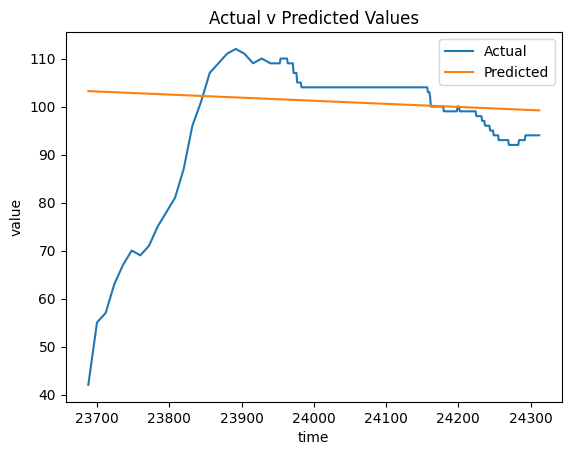

In [13]:
plt.plot(df["Time"], df["Value"], label="Actual")
plt.plot(df["Time"], df["Predicted"], label="Predicted")
plt.legend()
plt.title("Actual v Predicted Values")
plt.xlabel("time")
plt.ylabel("value")
plt.show()